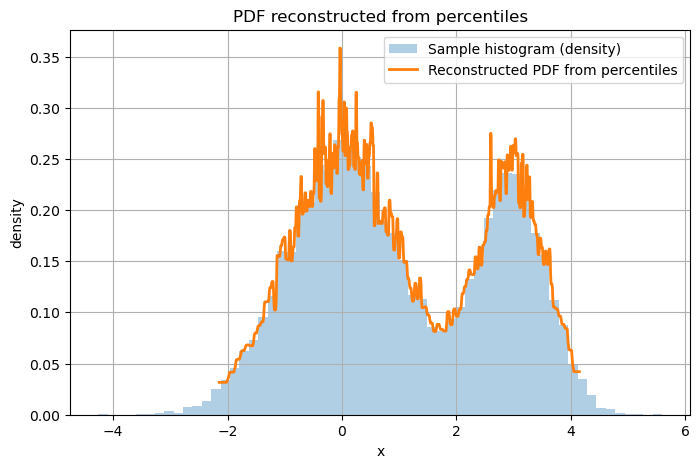

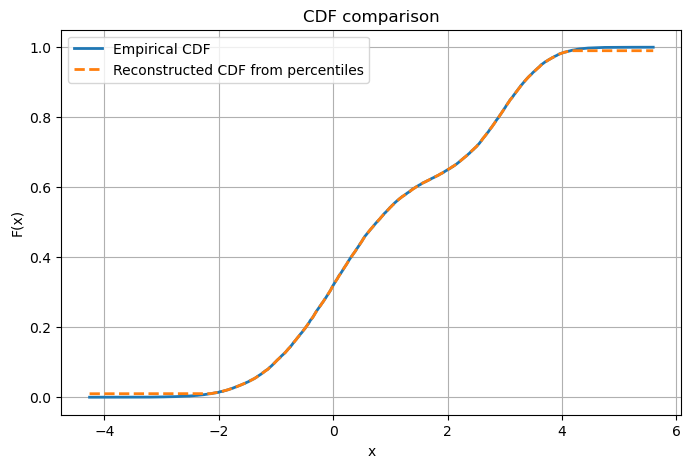

0.03083126934852224

In [20]:
# Reconstruct a PDF from percentiles (worked example)
# --------------------------------------------------
# We'll:
# 1) Simulate data from a nontrivial distribution (a mixture of Gaussians)
# 2) Compute many percentiles (quantiles)
# 3) Interpolate the quantile function Q(p)
# 4) Differentiate Q(p) to estimate the PDF via f(x) = 1 / Q'(p) evaluated at x = Q(p)
# 5) Normalize and compare to the sample histogram
# 6) Also reconstruct the CDF and compare to the empirical CDF

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# 1) Simulate data: mixture of two Gaussians (nonparametric shape)
n = 20000
mix = rng.uniform(size=n) < 0.65
data = np.empty(n)
data[mix] = rng.normal(loc=0.0, scale=1.0, size=mix.sum())
data[~mix] = rng.normal(loc=3.0, scale=0.6, size=(~mix).sum())

# 2) Compute percentiles (quantiles)
#    Use a dense grid of probabilities p in (0,1).
p_grid = np.linspace(0.01, 0.99, 199)  # 1%..99% (199 points)
Q = np.percentile(data, q=100 * p_grid)

# 3) Interpolate Q(p) on a finer probability grid
p_fine = np.linspace(0.01, 0.99, 999)
Q_fine = np.interp(p_fine, p_grid, Q)  # piecewise-linear, monotone by construction

# 4) Differentiate Q(p) -> Q'(p), then f(x)=1/Q'(p) evaluated at x=Q(p)
# Use finite differences on p_fine
dQdp = np.empty_like(Q_fine)
# central differences for interior points
dQdp[1:-1] = (Q_fine[2:] - Q_fine[:-2]) / (p_fine[2:] - p_fine[:-2])
# one-sided at boundaries
dQdp[0] = (Q_fine[1] - Q_fine[0]) / (p_fine[1] - p_fine[0])
dQdp[-1] = (Q_fine[-1] - Q_fine[-2]) / (p_fine[-1] - p_fine[-2])

# Estimate PDF on the parametric curve (x_i = Q_fine[i], f_i = 1/dQdp[i])
f_est = 1.0 / dQdp
# Guard against tiny numerical slopes in extreme tails
f_est = np.clip(f_est, 0, np.quantile(f_est, 0.999))

# Sort by x to prepare for plotting/integration
order = np.argsort(Q_fine)
x_pdf = Q_fine[order]
f_pdf = f_est[order]

# 5) Normalize area under curve (small correction from discretization)
area = np.trapz(f_pdf, x_pdf)
if area > 0:
    f_pdf /= area

# Plot: Histogram of data (density) vs reconstructed PDF
plt.figure(figsize=(8,5))
plt.hist(data, bins=60, density=True, alpha=0.35, label="Sample histogram (density)")
plt.plot(x_pdf, f_pdf, linewidth=2.0, label="Reconstructed PDF from percentiles")
plt.xlabel("x")
plt.ylabel("density")
plt.title("PDF reconstructed from percentiles")
plt.legend()
plt.grid(True)
plt.show()

# 6) Reconstruct CDF and compare to empirical CDF
# We already have pairs (x=Q_fine, p=p_fine). Interpolate p as a function of x.
# Build a monotone mapping x->p on the sorted arrays:
p_from_x = np.interp(x_pdf, x_pdf, p_fine[order])  # identity, here for clarity

# Empirical CDF
data_sorted = np.sort(data)
ecdf_y = np.arange(1, len(data_sorted)+1) / len(data_sorted)

# For a fair comparison, evaluate reconstructed CDF on the same x grid as the ECDF
F_recon_on_data = np.interp(data_sorted, x_pdf, p_from_x)

plt.figure(figsize=(8,5))
plt.plot(data_sorted, ecdf_y, linewidth=2.0, label="Empirical CDF")
plt.plot(data_sorted, F_recon_on_data, linewidth=2.0, linestyle="--", label="Reconstructed CDF from percentiles")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("CDF comparison")
plt.legend()
plt.grid(True)
plt.show()

# Optional diagnostic: L1 error between ECDF and reconstructed CDF on this grid
l1_err = np.trapz(np.abs(ecdf_y - F_recon_on_data), data_sorted)
l1_err
